# Explorando el Universo Latente: Introducción a Stable Diffusion

Objetivo: Comprender cómo funcionan los modelos de difusión generativa y generar imágenes a partir de descripciones textuales usando Stable Diffusion.

## 1. Instalación de Dependencias

In [1]:
!pip install diffusers transformers accelerate --upgrade
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transformers-5.9.0


## 2. Verificar GPU

In [1]:
import torch

print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


GPU disponible: True
GPU: Tesla T4


## 3. Importar Librerías

In [2]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## 4. Cargar el Modelo Preentrenado

In [3]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## 5. Primera Imagen

  0%|          | 0/50 [00:00<?, ?it/s]

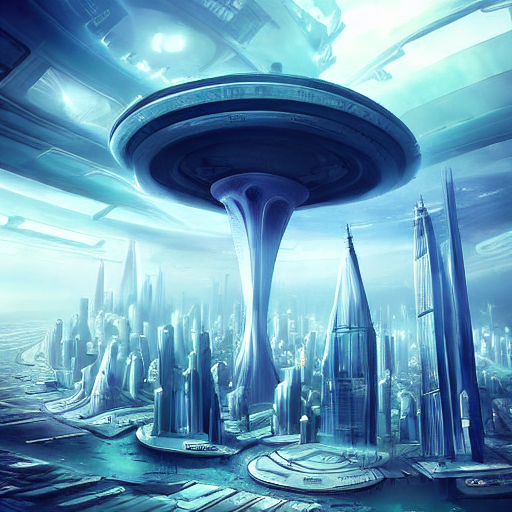

In [4]:
prompt = "A surreal futuristic city in the clouds, digital art"

image = pipe(
    prompt,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

image


## 6. Guardar la Imagen

In [5]:
image.save("ciudad_futurista.png")
print("Imagen guardada correctamente")


Imagen guardada correctamente


## 7. Visualizar la Imagen

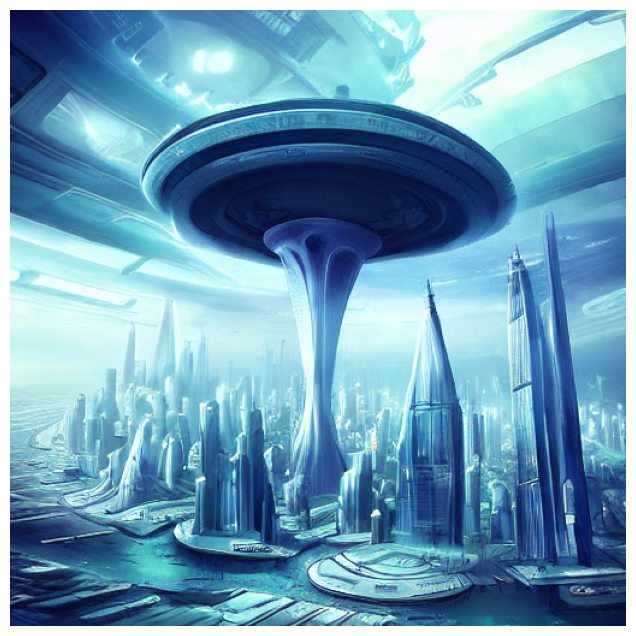

In [6]:
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()


## 8. Explorar Guidance Scale

In [7]:
prompt = "A magical forest with glowing trees"

guidance_values = [5, 7.5, 12]
imagenes = []

for g in guidance_values:
    img = pipe(
        prompt,
        guidance_scale=g,
        num_inference_steps=50
    ).images[0]
    imagenes.append(img)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

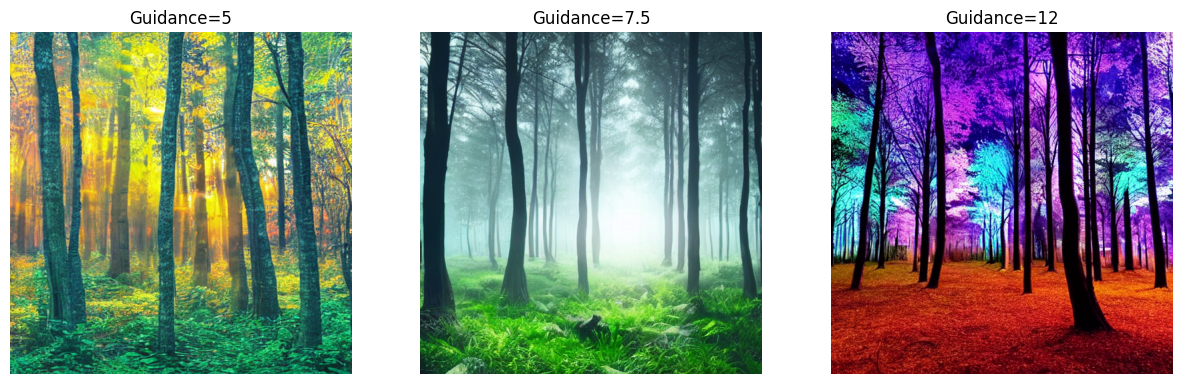

In [8]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

for ax, img, g in zip(axes, imagenes, guidance_values):
    ax.imshow(img)
    ax.set_title(f"Guidance={g}")
    ax.axis("off")

plt.show()


## 9. Explorar Diferentes Estilos

In [9]:
prompts = [
    "A castle on a mountain, oil painting",
    "A castle on a mountain, cyberpunk style",
    "A castle on a mountain, photorealistic"
]

imagenes = []

for p in prompts:
    img = pipe(
        p,
        num_inference_steps=50,
        guidance_scale=7.5
    ).images[0]
    imagenes.append(img)


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

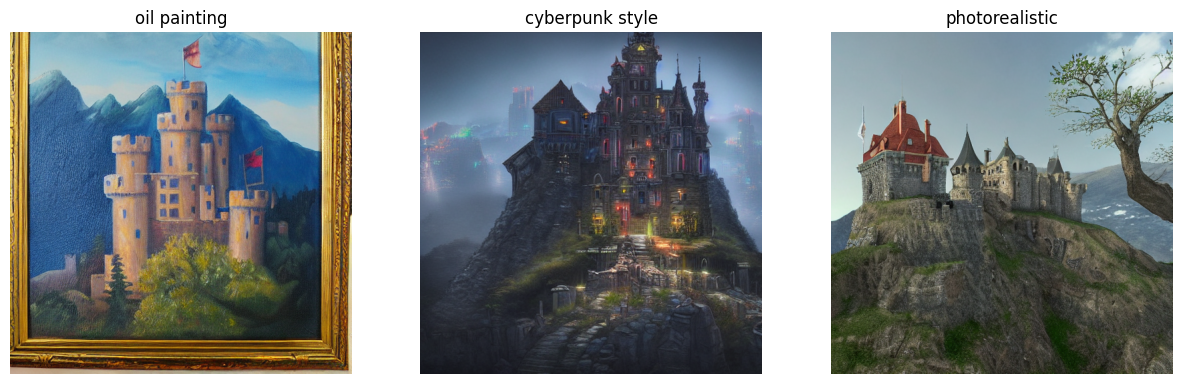

In [10]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

for ax, img, texto in zip(axes, imagenes, prompts):
    ax.imshow(img)
    ax.set_title(texto.split(",")[1].strip())
    ax.axis("off")

plt.show()


## 10. Uso de Seed

  0%|          | 0/50 [00:00<?, ?it/s]

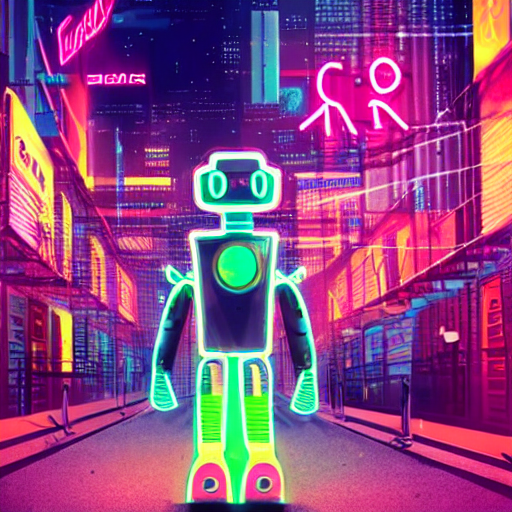

In [11]:
generator = torch.manual_seed(42)

prompt = "A futuristic robot walking through a neon city"

image_seed = pipe(
    prompt,
    generator=generator,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

image_seed


## 11. Cambiar Resolución

  0%|          | 0/50 [00:00<?, ?it/s]

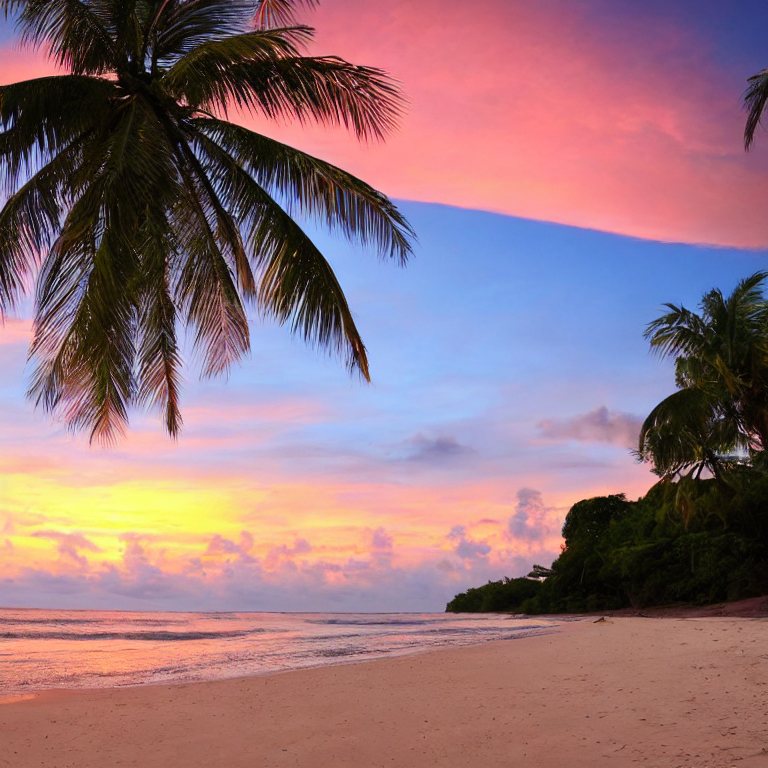

In [12]:
prompt = "A beautiful tropical beach at sunset"

image_hd = pipe(
    prompt,
    height=768,
    width=768,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

image_hd


## 12. Guardar Resultados Finales

In [13]:
image_hd.save("playa_hd.png")
image_seed.save("robot_seed42.png")

print("Resultados almacenados correctamente")


Resultados almacenados correctamente
